In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Atenção, nesse gerador G = 1 e Massa = Mearth e Distância = Rearth.

In [2]:
nParticles = 50000
mEarth = 1
rEarth = 1
Tot_mParticles = mEarth * 1e-4 # lembrando que mLua = 0.0123 mTerra

In [3]:
# powerlaw functions
# for particles location inner cutoff = central body radius 0.01, outer cutoff = 0.5 to 2 cb radius
def powerlaw(slope, min, max, y=0):
    if y == 0: y = np.random.uniform()
    pow_max = pow(max, slope+1.)
    pow_min = pow(min, slope+1.)
    return pow((pow_max-pow_min)*y + pow_min, 1./(slope+1.))

def rPar_kokubo(norm_mass, norm_rho, rad):
    return norm_mass**1./3. * norm_rho**-1./3. * rad

# for particles sizes with slope = 1.5, inner/outer mass cutoff = m_max / m_min = 1000
def mPar_kokubo(nPar, cutoff_ratio=1000, slope=-1.5, min=Tot_mParticles/nParticles/20):
    max = min * cutoff_ratio
    mass = np.zeros((nPar))
    #while np.sum(mass) < mass_tot:
    if slope == "INFINITY":
        for N in range(nPar):
            mass[N] = Tot_mParticles/nParticles
    else:
        for N in range(nPar):
            mass[N] = powerlaw(slope, min, max)
    return mass

Massa total em partículas calculada: 0.00010000000000000003 | 0.0001
Razão m_max/m_min: 1.0
Raio m_max: 8651.731963746282


<>:32: SyntaxWarning: invalid escape sequence '\o'
<>:32: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_50460/2812536740.py:32: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel('Massa (M$_{\ocirc}$)')


Text(0.5, 1.0, 'Power-law para massa de particulas')

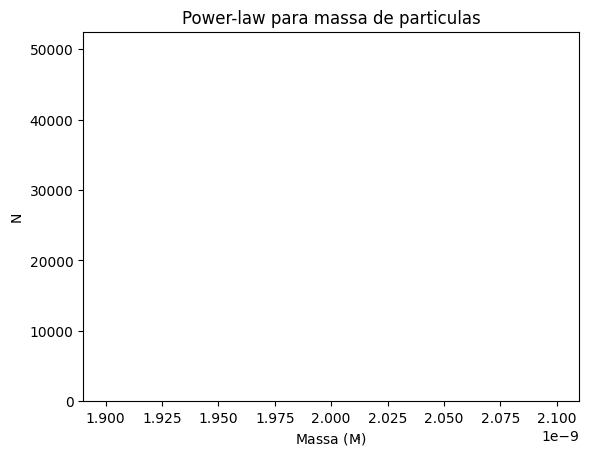

In [ ]:
volEarth = 4/3*np.pi*rEarth**3
dEarth = mEarth/volEarth

# Earth dependent units!!! Para chariklo aqui entre a razão das densidades do disco e do planeta
dParticles = dEarth*1.0/1.25215
# bulk density chariklo = 1.25215 g/cm^3 
# density das particulas = 1 g/cm^3

# Fator de proporcionalidade
fator = 0.1 # Isso aqui deve ser mudado se vc mudar a massa total em partículas e Npar

# mass distribution
OK = False
Try = 0
while OK is False:
    mParticles_ = mPar_kokubo(nParticles, slope="INFINITY", min=Tot_mParticles*fator/nParticles)
    diff = Tot_mParticles - np.sum(mParticles_)
    if abs(diff) < (Tot_mParticles*0.01):
        #print (abs(diff), (Tot_mParticles*0.1), fator)
        OK = True
    elif Try > 2:
        fator = fator*(1 + diff/np.sum(mParticles_))
    else:
        Try += 1
        print (f"Massa total em partículas calculada (fail {Try}): {np.sum(mParticles_)} | {Tot_mParticles}")
        print (f"Razão m_max/m_min: {np.max(mParticles_)/np.min(mParticles_)}")
print (f"Massa total em partículas calculada: {np.sum(mParticles_)} | {Tot_mParticles}")
print (f"Razão m_max/m_min: {np.max(mParticles_)/np.min(mParticles_)}")
print (f"Raio m_max: {(np.max(mParticles_)/dParticles * 3/4/np.pi)**(1./3.)*6371e3}")
#print (f"Raio m_min for Chariklo: {(np.max(mParticles_)*6.3e18/800e3 * 3/4/np.pi)**(1./3.)}")
plt.hist(mParticles_, bins=np.linspace(np.min(mParticles_), np.max(mParticles_), 50))
plt.xlabel('Massa (M$_{\ocirc}$)')
plt.ylabel('N')
plt.title('Power-law para massa de particulas')



Fator: 701000
Acabaram as partículas no bin 50!


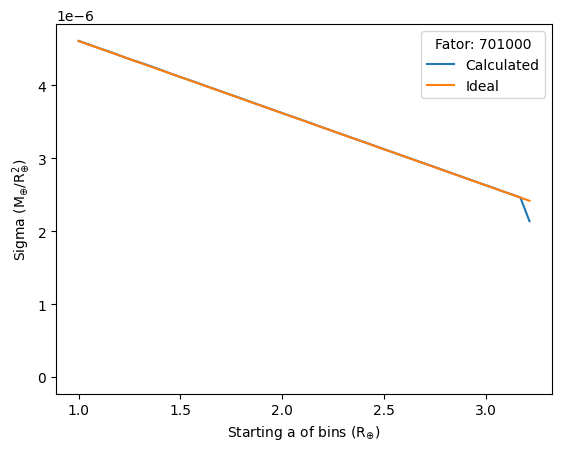

In [6]:
%matplotlib inline
# lets divide the disk into 50 radial symmetric rings, where the surface density is forced to match the power-law
beta = 0
a_inner_cutoff = 1*rEarth # rChariklo = 124 km raio equivalente
a_outer_cutoff = 1*rEarth*3.26 # distribuindo as partículas até ~405km
# calculating bins positions and areas
aBins = np.linspace(a_inner_cutoff, a_outer_cutoff, 51)
Area_aBins = [np.pi*(aBins[i+1]**2 - aBins[i]**2) for i in range(aBins.size-1)]

plt.ion()
fig, plot = plt.subplots()
plot.set_xlabel('Starting a of bins (R$_{\\oplus}$)')
plot.set_ylabel('Sigma (M$_{\\oplus}$/R$_{\\oplus}^2$)')

# Fator de proporcionalidade
fator2 = 701000 # Isso aqui deve ser mudado se vc mudar qualquer dimensão do anel ou dos bins
fator2_up = []
fator2_down = []

flag_doitagain = True
sigmaPowerLaw = [powerlaw(beta, a_inner_cutoff, a_outer_cutoff, y=a/max(aBins))/fator2 for a in aBins]
sigmaPowerLaw = np.array(sigmaPowerLaw[:-1][::-1])
sigma_aux_ = np.zeros((aBins.shape[0]-1))
l1, = plot.plot(aBins[:-1], sigma_aux_, label="Calculated")
l2, = plot.plot(aBins[:-1], sigmaPowerLaw, label="Ideal")
legenda = plot.legend(title=f"fator: {fator2}")
print (f"Fator: {fator2}")

while flag_doitagain is True:
    df = pd.DataFrame({'mass': [], 'a_i': [], 'a_f': [], 'radius': [], 'density': []})
    # semi-axis power-law
    sigmaPowerLaw = [powerlaw(beta, a_inner_cutoff, a_outer_cutoff, y=a/max(aBins))/fator2 for a in aBins]
    sigmaPowerLaw = np.array(sigmaPowerLaw[:-1][::-1])
    flag_doitagain = False # GAMBIARRA

    # cada segmento de anel seguirá a Rayleigh para os valores RMS de ecc e inc, independentemente.
    mParticles_aux_ = mParticles_ # pote de partículas para preencher os bins
    sigma_aux_ = np.zeros((aBins.shape[0]-1))
    flag, flag2 = False, False
    for i in range(sigmaPowerLaw.size):
        while sigma_aux_[i] < sigmaPowerLaw[i]:
            try:
                iPar = np.random.choice(len(mParticles_aux_)) # selecionar uma partícula aleatória do pote
            except:
                print (f"Acabaram as partículas no bin {i+1}!")
                if sigma_aux_[-1] < sigmaPowerLaw[-1]*0.75: #and i < sigmaPowerLaw.size:
                    if sigma_aux_[-1] == 0: 
                        fator2 = fator2*(1 + np.count_nonzero(sigma_aux_ == 0)/sigmaPowerLaw.size)
                    else: fator2 = fator2*(1.10)
                    print (f"Fail up para fator: {fator2}")
                else: flag2 = True
                #elif sigma_aux_[i] < sigmaPowerLaw[i]*0.75 and i == sigmaPowerLaw.size:
                #    fator2_down.append(fator2)
                #    fator2 = max(fator2_down)*(1 + 0.05)
                flag = True
                if flag: break
            mPar = mParticles_aux_[iPar] # massa da partícula selecionada do pote
            sigma_aux_[i] += mPar/Area_aBins[i]

            rad = (mPar/dParticles * 3/4/np.pi)**(1./3.)
            df_aux = pd.DataFrame({'mass': [mPar], 'a_i': [aBins[i]], 'a_f': [aBins[i+1]], 'radius': [rad], 
                                'density': [dParticles]})
            df = pd.concat([df,df_aux])

            # Remover a partícula adiiciona ao bin do pote
            mParticles_aux_ = np.delete(mParticles_aux_, iPar)
        if flag: break
    if mParticles_aux_.size > 0 and (sigma_aux_[-1] + np.sum(mParticles_aux_)/Area_aBins[-1]) < 1.25*sigmaPowerLaw[-1]:
        print (f"Foram inseridas {mParticles_aux_.size} extras no ultimo bin! {fator2}")
        while mParticles_aux_.size > 0:
            mPar = mParticles_aux_[0]
            sigma_aux_[-1] += mPar/Area_aBins[-1]
            mParticles_aux_ = np.delete(mParticles_aux_, 0)

            rad = (mPar/dParticles * 3/4/np.pi)**(1./3.)
            df_aux = pd.DataFrame({'mass': [mPar], 'a_i': [aBins[-2]], 'a_f': [aBins[-1]], 'radius': [rad], 
                                'density': [dParticles]})
            df = pd.concat([df,df_aux])
        flag_doitagain = False
    elif mParticles_aux_.size > 0:
        fator2 = fator2*(1 + (np.sum(sigmaPowerLaw) - (np.sum(sigma_aux_) + np.sum(mParticles_aux_)/Area_aBins[-1]))/np.sum(sigmaPowerLaw))
        print (f"Fail down para fator: {fator2}")
    elif flag2:
        flag_doitagain = False
    #print (flag_doitagain)
    #print (f"Fator: {fator2}")
        
l1.set_data(aBins[:-1], sigma_aux_)
l2.set_data(aBins[:-1], sigmaPowerLaw)
legenda.set_title(f"Fator: {fator2}")

#simga chariklo
# sigma = np.mean(sigmaPowerLaw)*6.3e18/125e3/125e3
# print (sigma)

# Redesenha o gráfico
fig.canvas.draw()
fig.canvas.flush_events()

#print(df)

In [9]:
flagP_ecc = 0
i = 0
print (df)
while i < aBins.size-1:
    aux = (df["a_i"] == aBins[i])
    df_aux = df[aux]
    #print (df_aux)

    Nbin = len(df_aux)
    e_ = np.random.default_rng().rayleigh(0.1, Nbin)
    inc_ = np.random.default_rng().rayleigh(0.05, Nbin)
    rms_e = np.sqrt(np.mean(e_**2))
    rms_i = np.sqrt(np.mean(inc_**2))
    a_ = np.random.uniform(aBins[i], aBins[i+1], Nbin)
    omega_ = np.random.uniform(0, 2.*np.pi, Nbin)
    Omega_ = np.random.uniform(0, 2.*np.pi, Nbin)
    M_ = np.random.uniform(0, 2.*np.pi, Nbin)

    #print(f"Bin {i+1}-> RMS ecc: {rms_e} | RMS inc: {rms_i} | RMS ecc/RMS inc: {rms_e/rms_i}")
    # below 5% of error

    # Testa se a particula tem pericentro dentro da Terra
    j = 0
    while j < Nbin:
        pericentre_radius = a_[j]*(1 - e_[j])
        if pericentre_radius <= 1:
            e_[j] = e_[j]*0.5
            flagP_ecc += 1
        else:
            j += 1

    rms_e = np.sqrt(np.mean(e_**2))
    rms_i = np.sqrt(np.mean(inc_**2))
    # Attenção, esse print aaixo mostra que os bins iniciais não seguem a regra de Kokubo para e/i RMS
    print(f"Bin {i+1}-> RMS ecc: {rms_e} | RMS inc: {rms_i} | RMS ecc/RMS inc: {rms_e/rms_i}")

    i += 1        
    df.loc[aux, 'a'] = a_
    df.loc[aux, 'e'] = e_
    df.loc[aux, 'inc'] = inc_
    df.loc[aux, 'omega'] = omega_
    df.loc[aux, 'Omega'] = Omega_
    df.loc[aux, 'M'] = M_

    #test_particles
    df.loc[aux, 'mass'] = np.zeros(Nbin)
    df.loc[aux, 'radius'] = np.zeros(Nbin)

print(df)

            mass     a_i     a_f    radius   density         a         e  \
0   2.000000e-09  1.0000  1.0452  0.001358  0.190658  1.008691  0.007102   
0   2.000000e-09  1.0000  1.0452  0.001358  0.190658  1.036825  0.022210   
0   2.000000e-09  1.0000  1.0452  0.001358  0.190658  1.039605  0.019260   
0   2.000000e-09  1.0000  1.0452  0.001358  0.190658  1.043290  0.032419   
0   2.000000e-09  1.0000  1.0452  0.001358  0.190658  1.016574  0.012524   
..           ...     ...     ...       ...       ...       ...       ...   
0   2.000000e-09  3.2148  3.2600  0.001358  0.190658  3.227845  0.219975   
0   2.000000e-09  3.2148  3.2600  0.001358  0.190658  3.237944  0.194649   
0   2.000000e-09  3.2148  3.2600  0.001358  0.190658  3.234205  0.142757   
0   2.000000e-09  3.2148  3.2600  0.001358  0.190658  3.229049  0.137496   
0   2.000000e-09  3.2148  3.2600  0.001358  0.190658  3.244094  0.051703   

         inc     omega     Omega         M  
0   0.052753  5.626737  2.174765  1.022945

In [10]:


import pathlib, sys, os
from datetime import datetime
date = datetime.now()
path = pathlib.Path(os.getcwd()).absolute()
aux_path = path/f'Inputs/'
my_input_name = "chariklo_tp"
np.savetxt(aux_path/f"disc_{my_input_name}.in", df.values, delimiter='\t')